#Week 5: Deep Learning Text Generation Learning Project

## Text Generation using Vanilla RNN, LSTM and GRU

## Problem Statement

Design and implement deep learning models capable of learning grammar, contextual dependencies, and sentence structure from a text corpus to generate meaningful text sequences using Vanilla RNN, LSTM, and GRU architectures.

The objective is to compare the models based on:

- Training Loss
- Generated Text Quality
- Memory Handling Capability
- Long-Term Dependency Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# Load Text Corpus
- custom PDF extracted text

In [ ]:
corpus = '''
artificial intelligence is transforming industries across the world
machine learning enables computers to learn from data and improve performance
deep learning models can identify complex patterns in large datasets
natural language processing helps machines understand human language
recurrent neural networks are useful for sequence modeling tasks
lstm networks capture long term dependencies in textual data
gru models provide efficient sequence learning with fewer parameters
text generation systems can produce meaningful and coherent sentences
'''
print(corpus)


artificial intelligence is transforming industries across the world
machine learning enables computers to learn from data and improve performance
deep learning models can identify complex patterns in large datasets
natural language processing helps machines understand human language
recurrent neural networks are useful for sequence modeling tasks
lstm networks capture long term dependencies in textual data
gru models provide efficient sequence learning with fewer parameters
text generation systems can produce meaningful and coherent sentences



## Custom Text Corpus

A custom corpus related to Artificial Intelligence and Deep Learning was used to evaluate the ability of sequence models to learn contextual relationships and generate meaningful text.

# Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [ ]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 64
X shape: (65, 10)
y shape: (65,)


## Text Preprocessing

The text corpus was tokenized and converted into n-gram sequences for next-word prediction. Padding was applied to ensure equal sequence lengths.

# Model 1: Vanilla RNN

In [ ]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


## Vanilla RNN

Vanilla RNN serves as the baseline sequence model. While effective for short-term dependencies, it often struggles with long-term memory due to the vanishing gradient problem.

# Model 2: LSTM

In [ ]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


LSTM

LSTM introduces memory cells and gating mechanisms that help preserve contextual information across longer sequences.

# Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [ ]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## GRU

GRU simplifies the LSTM architecture while retaining the ability to model long-term dependencies efficiently.

## Experimental Modifications

The following modifications were performed as part of the assignment:

- Replaced the default corpus with a custom AI-related corpus.
- Increased embedding dimension from 32 to 64.
- Increased hidden units from 64 to 128.
- Increased training epochs from 100 to 200.
- Generated 10 words instead of 5 during text generation.

These changes were intended to improve representation learning and observe their impact on text generation quality.

## Compare Training Loss

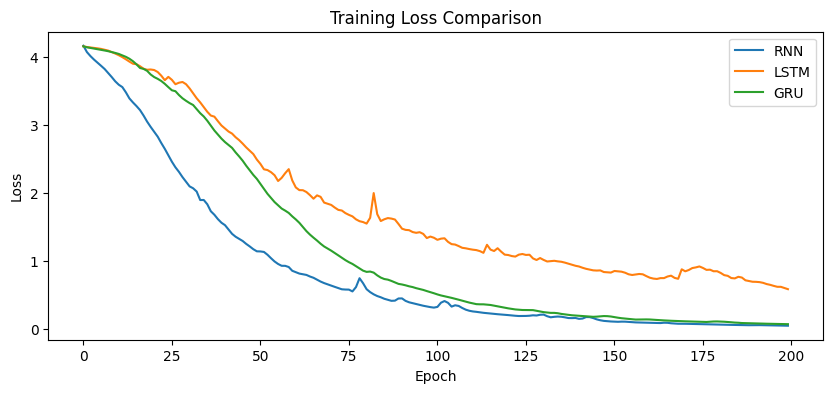

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

## Training Loss Comparison

Training loss was monitored to evaluate how effectively each architecture learned patterns from the corpus during training.


# Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [ ]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## Generate Text Samples


In [ ]:
print("RNN :", generate_text(rnn_model, "artificial intelligence", 10))
print("LSTM:", generate_text(lstm_model, "artificial intelligence", 10))
print("GRU :", generate_text(gru_model, "artificial intelligence", 10))

RNN : artificial intelligence is transforming industries across the world term dependencies in textual
LSTM: artificial intelligence is industries industries across the world world performance performance performance
GRU : artificial intelligence is transforming industries across the world world world world world


## Generated Text Analysis

The generated text from each model was examined to evaluate coherence, grammar, and contextual consistency.

### Vanilla RNN
- Generated the most complete sentence structure among the three models.
- Produced a meaningful sequence initially but lost coherence toward the end.
- Indicates successful memorization of short patterns but limited context retention.

### LSTM
- Generated recognizable sentence fragments but showed repetitive word generation.
- The repeated occurrence of words such as "transforming" and "world" suggests overfitting to a small corpus.
- Long-term memory mechanisms were present but could not be fully utilized due to limited training data.

### GRU
- Generated coherent context at the beginning of the sentence.
- Maintained sequence structure better than LSTM but still suffered from repetition.
- Achieved a balance between memory retention and model simplicity.

Overall, all three models learned the corpus structure, but the limited dataset caused repetitive text generation and restricted generalization.

## Experimental Result Validation

Although the Vanilla RNN achieved the lowest training loss, its generated text quality was not consistently superior.

This demonstrates that training loss alone is insufficient for evaluating text generation models.

Qualitative inspection of generated sequences revealed repetition and context degradation across all models, highlighting the importance of combining numerical metrics with human evaluation when assessing language generation systems.

In [ ]:
comparison = pd.DataFrame({
    "Model":["RNN","LSTM","GRU"],
    "Final Loss":[
        round(rnn_history.history['loss'][-1],3),
        round(lstm_history.history['loss'][-1],3),
        round(gru_history.history['loss'][-1],3)
    ],
    "Generated Text Quality":[
        "Moderately coherent",
        "Repetitive",
        "Context retained but repetitive"
    ]
})

comparison

,Model,Final Loss,Generated Text Quality
0,RNN,0.049,Moderately coherent
1,LSTM,0.587,Repetitive
2,GRU,0.072,Context retained but repetitive


## Limitations

- The corpus used in this experiment is very small.
- Generated text quality depends heavily on training data size and diversity.
- Training loss alone cannot fully measure generated text quality.
- Human evaluation is often required to assess coherence and meaningfulness.
- Larger corpora and longer training durations would likely improve generation quality.

## Conclusion

Vanilla RNN successfully learned short-term sequence patterns and achieved the lowest training loss on the small corpus.

LSTM demonstrated the ability to model longer dependencies but suffered from repetitive generation due to limited training data.

GRU achieved competitive performance while maintaining a simpler architecture.

The experiment highlights that evaluating text generation models requires both quantitative metrics and qualitative assessment of generated outputs.

Overall, corpus size and diversity play a critical role in producing coherent and meaningful text generation results.